# Lab02 - 2D CUDA Kernels

## Ex. 1) 2D Fibonacci

🔹 **Task Description**

-   You must write a CUDA kernel that:
    1.  Computes s (the thread index) using thread and block indices
    2.  Checks whether s is a Fibonacci number
    3.  Write 1 only if s is Fibonacci


N is fibonacci IFF (5 N^2 + 4) or (5N^2 – 4) are perfect squares

In [3]:
import numpy as np
import time
import math
import numba
from numba import cuda
from wurlitzer import sys_pipes

cuda.detect()

Found 1 CUDA devices
id 0                Tesla T4                              [SUPPORTED]
                      Compute Capability: 7.5
                           PCI Device ID: 4
                              PCI Bus ID: 0
                                    UUID: GPU-3e5ddd27-013c-3818-ed9f-6daba2e7464e
                                Watchdog: Disabled
             FP32/FP64 Performance Ratio: 32
Summary:
	1/1 devices are supported


True

Time: 0.13008880615234375s


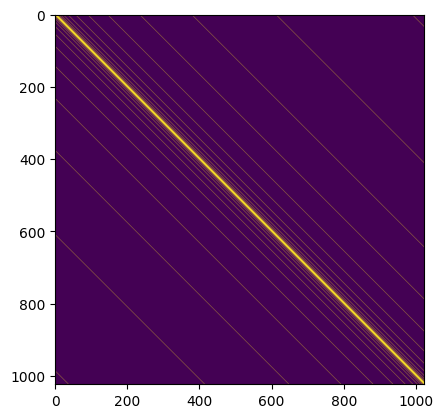

In [31]:
import matplotlib.pyplot as plt

SIZE = (1024, 1024)

out_host =  np.zeros(shape=SIZE)
out_device = cuda.device_array_like(out_host)


@cuda.jit(device=True, inline=True)
def is_perfect_square(n):
    return math.floor(math.sqrt(n)) ** 2 == n 

@cuda.jit(device=True, inline=True)
def is_fibonacci(n):
    return is_perfect_square(5 * n * n + 4) or is_perfect_square(5 * n * n - 4)

@cuda.jit
def find_fibonacci_cuda(out):
    col, row = cuda.grid(2) # x, y
    if row < out.shape[0] and col < out.shape[1]:
        if is_fibonacci(col - row):
            out[row, col] = 1
            
BLOCK_SIZE = (16, 16)
GRID_SIZE = ((SIZE[0] + BLOCK_SIZE[0] - 1) // BLOCK_SIZE[0],  (SIZE[1] + BLOCK_SIZE[1] - 1) // BLOCK_SIZE[1])

start = time.time()
with sys_pipes():
    find_fibonacci_cuda[GRID_SIZE, BLOCK_SIZE](out_device)
    cuda.synchronize()
end = time.time()

out_host = out_device.copy_to_host()

print(f"Time: {end - start}s")

plt.imshow(out_host)
plt.show()

## Ex. 2) Image Flipping

Image size: 1024 x 524 x 3


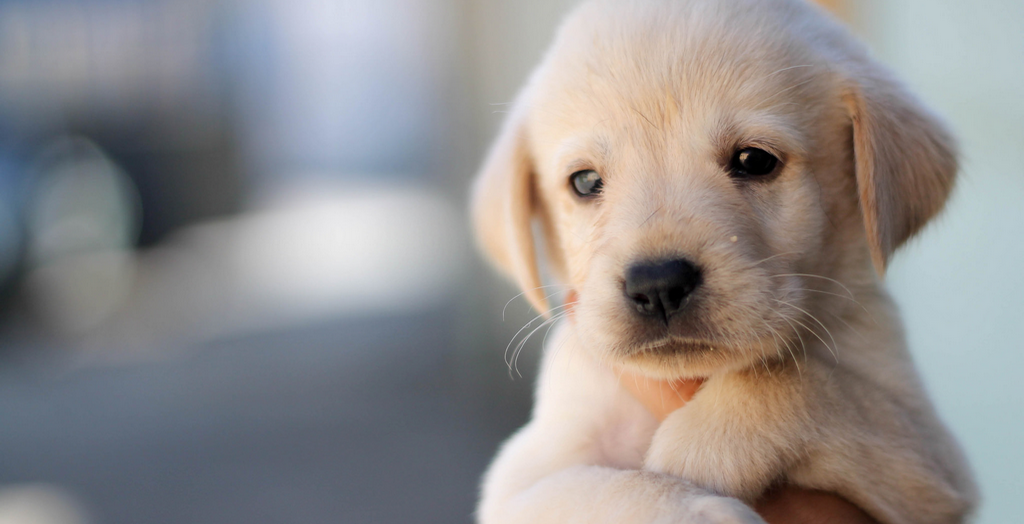

In [34]:
import requests
import numpy as np
from PIL import Image
from io import BytesIO

url = "https://raw.githubusercontent.com/Filippo-Corti/GPUComputing/refs/heads/main/data/dog.bmp"

response = requests.get(url)

raw_img = Image.open(BytesIO(response.content))

img_host = np.array(raw_img).astype(np.uint8)
H, W, C = img_host.shape
print(f"Image size: {W} x {H} x {C}")
raw_img

Block Size: (16, 16)
Grid Size: (64, 33)


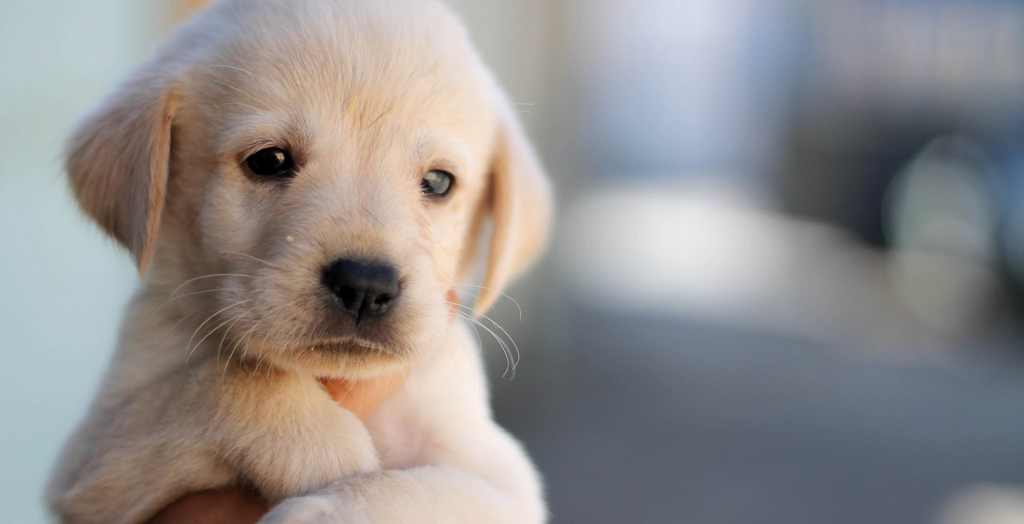

In [46]:
# Image Flip (Horizontal)

img_device = cuda.to_device(img_host)
out_img_device = cuda.device_array_like(img_device)

BLOCK_SIZE = (16, 16)
GRID_SIZE = ((W + BLOCK_SIZE[0] - 1) // BLOCK_SIZE[0], (H + BLOCK_SIZE[1] - 1) // BLOCK_SIZE[1])

print(f"Block Size: {BLOCK_SIZE}")
print(f"Grid Size: {GRID_SIZE}")

@cuda.jit
def flip_horizontally(inp, out):
    col, row = cuda.grid(2)
    
    if col >= W or row >= H:
        return
    
    new_col = W - 1 - col
    out[row, new_col, 0] = inp[row, col, 0]
    out[row, new_col, 1] = inp[row, col, 1]
    out[row, new_col, 2] = inp[row, col, 2]
    
with sys_pipes():
    flip_horizontally[GRID_SIZE, BLOCK_SIZE](img_device, out_img_device)
    cuda.synchronize()
    
out_img_host = out_img_device.copy_to_host()

Image.fromarray(out_img_host)

Block Size: (16, 16)
Grid Size: (64, 33)


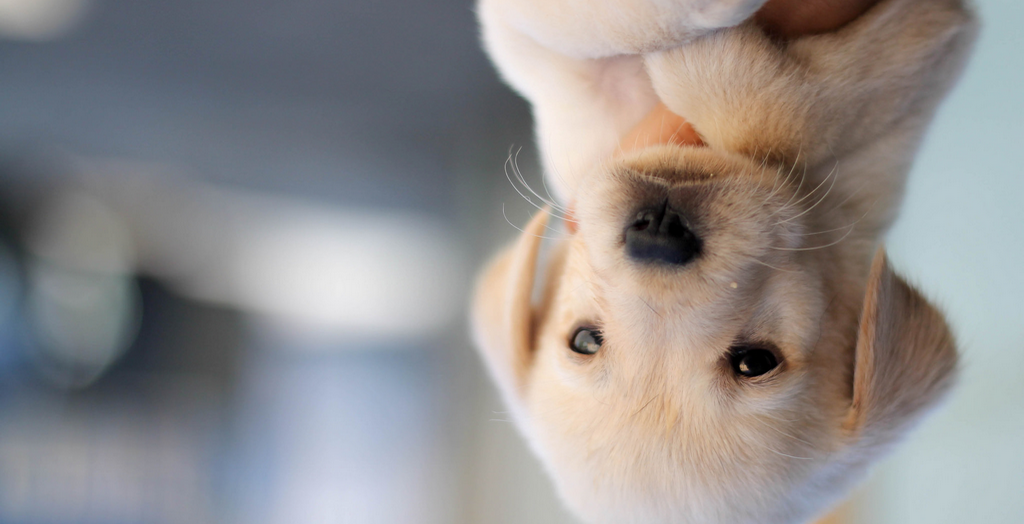

In [47]:
# Image Flip (Vertically)

img_device = cuda.to_device(img_host)
out_img_device = cuda.device_array_like(img_device)

BLOCK_SIZE = (16, 16)
GRID_SIZE = ((W + BLOCK_SIZE[0] - 1) // BLOCK_SIZE[0], (H + BLOCK_SIZE[1] - 1) // BLOCK_SIZE[1])

print(f"Block Size: {BLOCK_SIZE}")
print(f"Grid Size: {GRID_SIZE}")

@cuda.jit
def flip_vertically(inp, out):
    col, row = cuda.grid(2)
    
    if col >= W or row >= H:
        return
    
    new_row = H - 1 - row
    out[new_row, col, 0] = inp[row, col, 0]
    out[new_row, col, 1] = inp[row, col, 1]
    out[new_row, col, 2] = inp[row, col, 2]
    
with sys_pipes():
    flip_vertically[GRID_SIZE, BLOCK_SIZE](img_device, out_img_device)
    cuda.synchronize()
    
out_img_host = out_img_device.copy_to_host()

Image.fromarray(out_img_host)

## Ex. 2) Image Blurring

Block Size: (16, 16)
Grid Size: (64, 33)


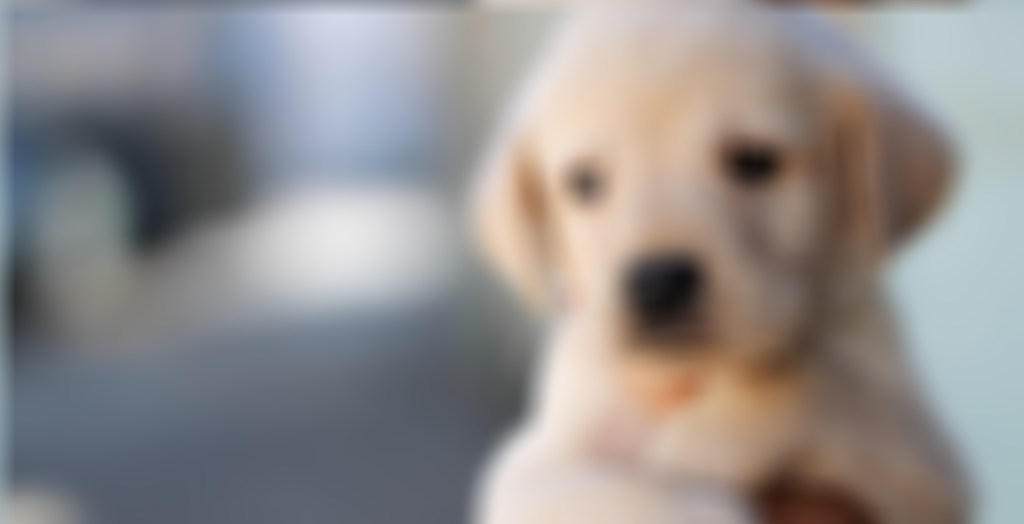

In [57]:
# In order to blur, each pixel should have a value corresponding to the average of all surrouding pixels

img_device = cuda.to_device(img_host)
out_img_device = cuda.device_array_like(img_device)

BLOCK_SIZE = (16, 16)
GRID_SIZE = ((W + BLOCK_SIZE[0] - 1) // BLOCK_SIZE[0], (H + BLOCK_SIZE[1] - 1) // BLOCK_SIZE[1])

print(f"Block Size: {BLOCK_SIZE}")
print(f"Grid Size: {GRID_SIZE}")

@cuda.jit
def blur(inp, out, k):
    col, row = cuda.grid(2)
    
    if col >= W or row >= H:
        return
    
    sumr, sumg, sumb = 0, 0, 0
    count = 0
    kernel_radius = k // 2 
    for dr in range(-kernel_radius, kernel_radius + 1):
        for dc in range(-kernel_radius, kernel_radius + 1):
            new_col = col + dc
            new_row = row + dr
            if new_col >= W or new_row >= H:
                continue
            
            sumr += inp[new_row, new_col, 0]
            sumg += inp[new_row, new_col, 1]
            sumb += inp[new_row, new_col, 2]
            count += 1
            
    out[row, col, 0] = sumr / count
    out[row, col, 1] = sumg / count
    out[row, col, 2] = sumb / count


blur[GRID_SIZE, BLOCK_SIZE](img_device, out_img_device, 30)
cuda.synchronize()

out_img_host = out_img_device.copy_to_host()

Image.fromarray(out_img_host)